<a href="https://colab.research.google.com/github/sarraz13/Donation-Management-Platform/blob/main/5feat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Setup terminé
Lignes : 8,310 | Compteurs : 176
Distribution CVI :
CVI
1.0     5222
6.0     1534
NaN     1503
96.0      18
95.0      17
3.0       16
Name: count, dtype: int64

TARGET — Normal: 1,503 (48.7%) | Anomalie: 1,585 (51.3%)

Dataset modèle : (2614, 5) | Anomalies : 1,583 (60.6%)
Train : 2,091 | Test : 523
Sans SMOTE — Normal: 825 | Anomalie: 1,266


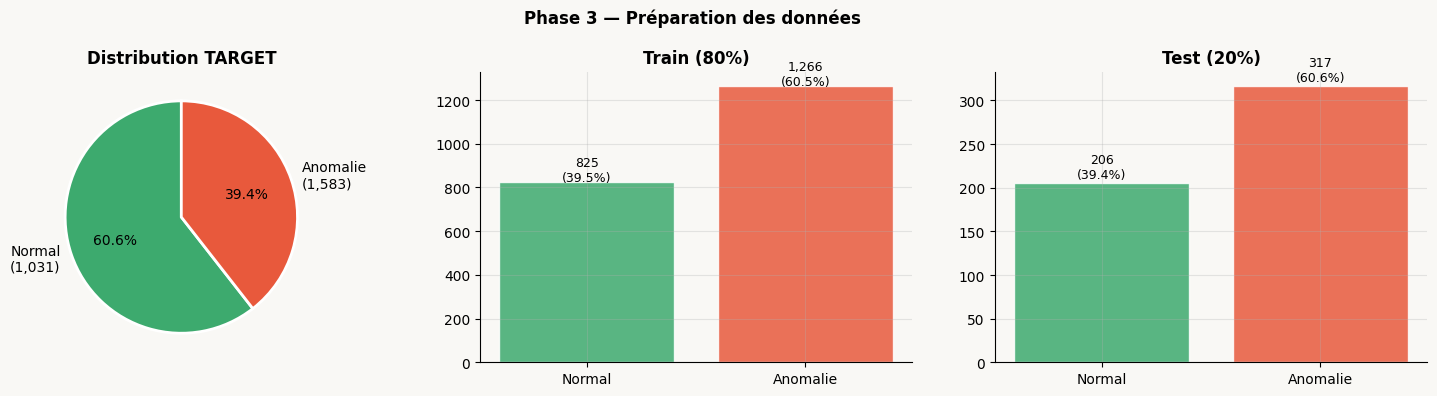

✅ Phase 3 terminée

══════════════════════════════════════════════════
  PHASE 4 — ENTRAÎNEMENT DES MODÈLES
══════════════════════════════════════════════════
LR    — Anomalies prédites : 361
RF    — Anomalies prédites : 320
XGB   — Anomalies prédites : 327
✅ Phase 4 terminée

══════════════════════════════════════════════════
  PHASE 5 — ÉVALUATION
══════════════════════════════════════════════════

📊 Tableau comparatif :

               Modèle  Précision  Rappel  F1-Score  AUC-ROC
Régression Logistique       81.4    92.7      86.7     74.8
        Random Forest       94.1    95.0      94.5     96.2
              XGBoost       93.6    96.5      95.0     96.8

✅ Meilleur modèle (F1) : XGBoost


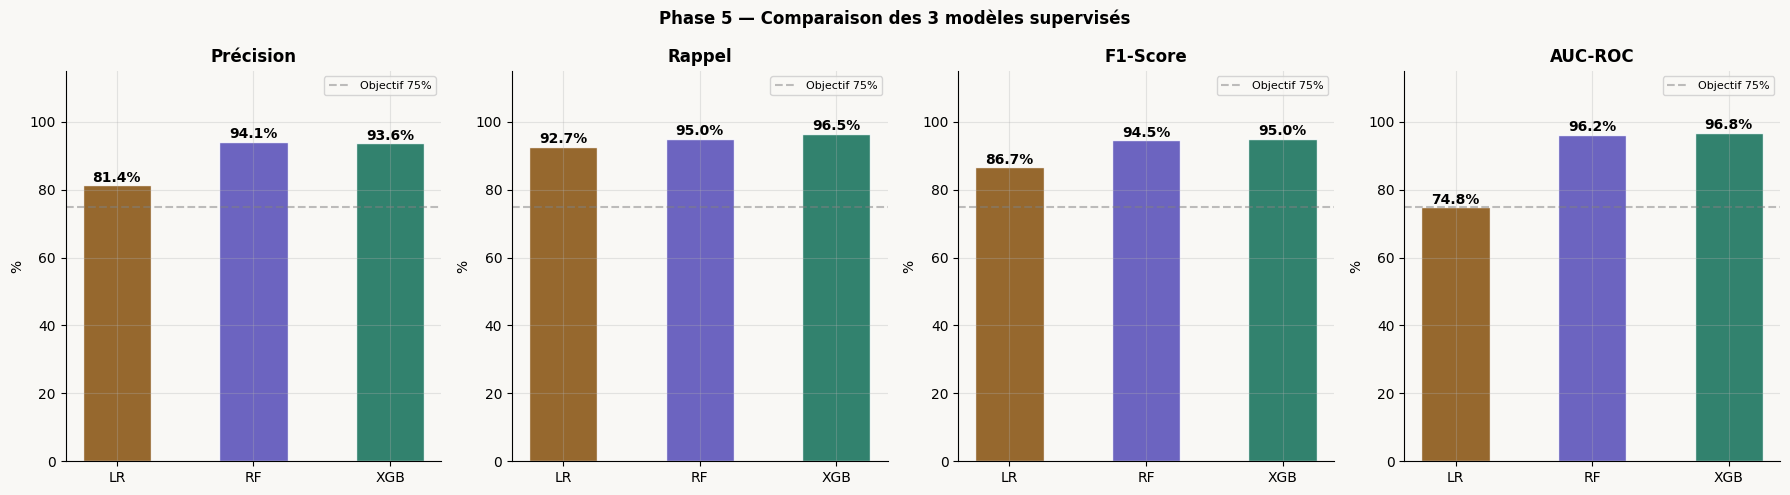

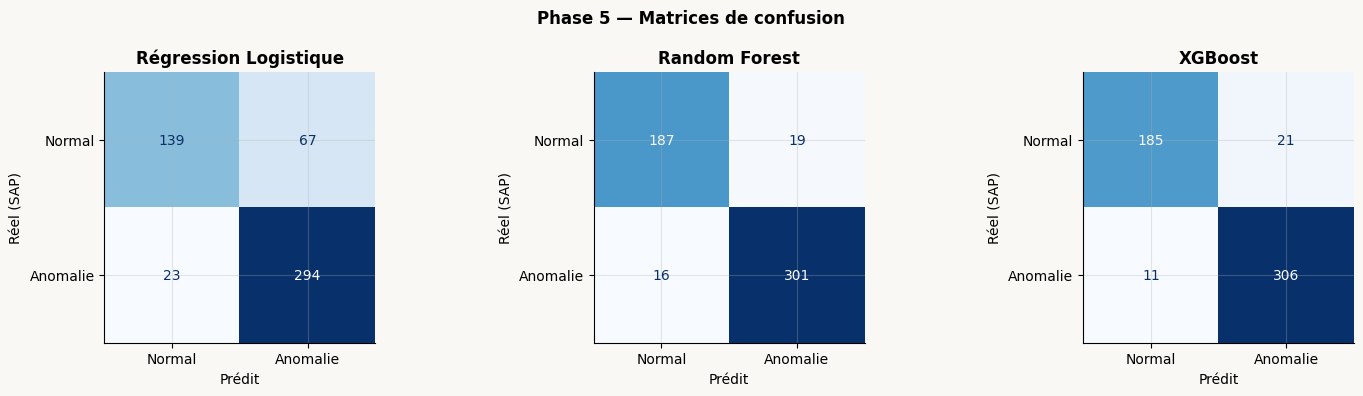

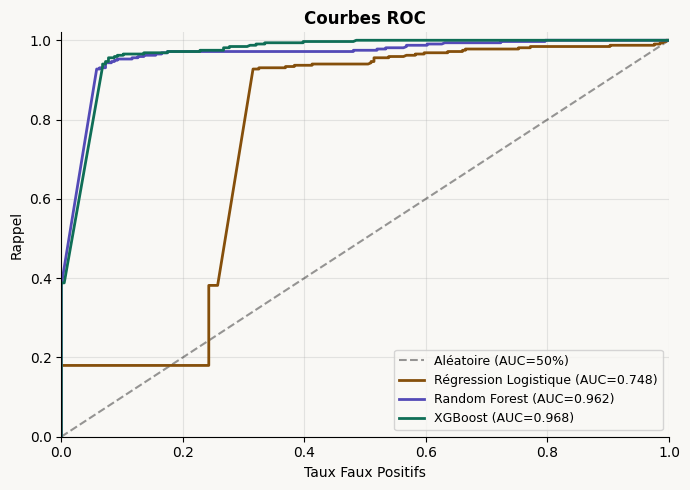

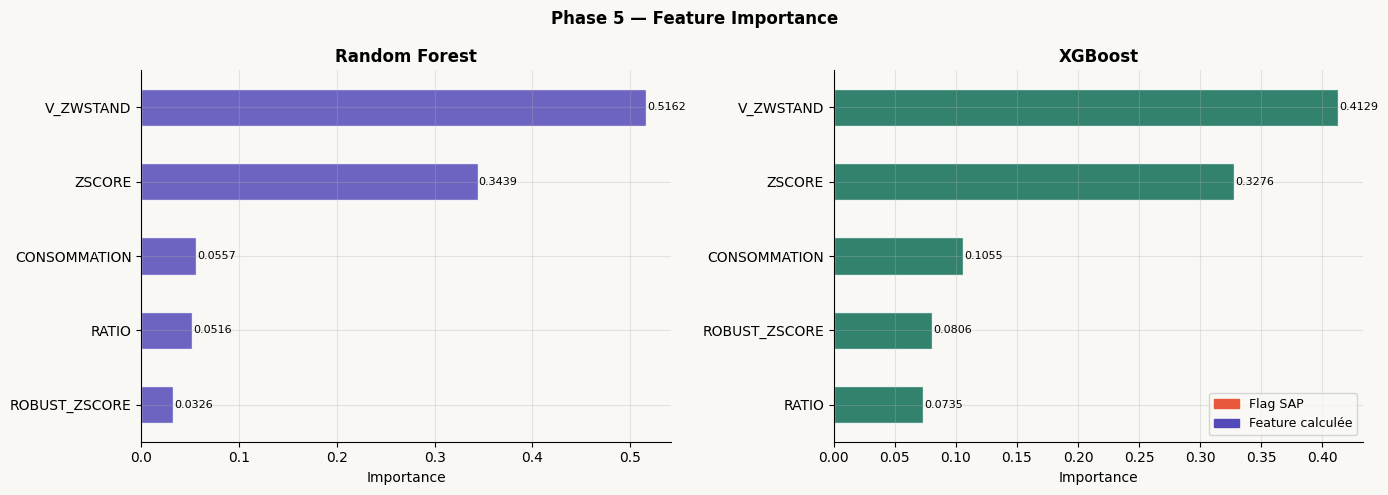


📊 Cross-Validation 5 folds :
  Régression Logistique     F1: 0.840 ± 0.014  ✅ stable
  Random Forest             F1: 0.928 ± 0.015  ✅ stable
  XGBoost                   F1: 0.932 ± 0.018  ✅ stable

📊 Test de surapprentissage (Train vs Test) :
  Modèle                      F1 Train    F1 Test      Écart Statut
  -----------------------------------------------------------------
  Régression Logistique         0.841      0.867     -0.027  ✅ généralise bien
  Random Forest                 0.936      0.945     -0.009  ✅ généralise bien
  XGBoost                       0.966      0.950     +0.016  ✅ généralise bien

  Modèle                     AUC Train   AUC Test      Écart
  ------------------------------------------------------------
  Régression Logistique         0.707      0.748     -0.041
  Random Forest                 0.967      0.962     +0.005
  XGBoost                       0.974      0.968     +0.006


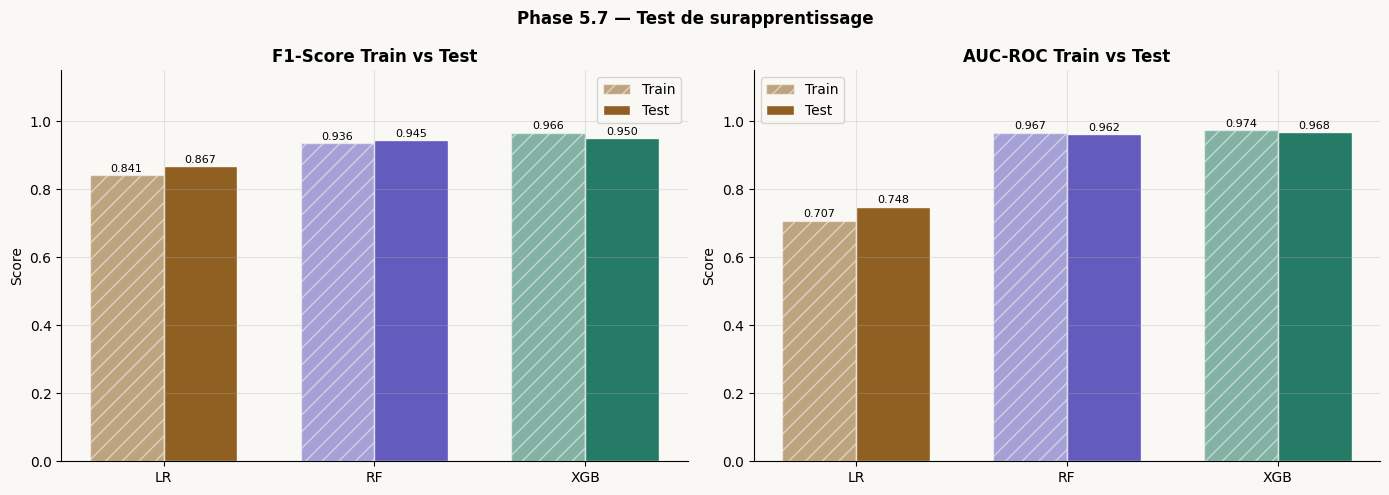

✅ Phase 5.7 terminée
✅ Modèles sauvegardés : xgboost.joblib + scaler.joblib

Résultats finaux :
STATUT
Anomalie    1628
Normal       986
Name: count, dtype: int64
✅ Export : resultats_supervise.csv

════════════════════════════════════════════════════════════
  RÉCAPITULATIF CRISP-DM
════════════════════════════════════════════════════════════
  1. Métier          CVI comme target SAP · exclusion CVI=01
  2. Données         Distribution · valeurs manquantes · stats
  3. Préparation     Nettoyage · features · split 80/20 · scaler · SMOTE
  4. Modélisation    LR · Random Forest · XGBoost
  5. Évaluation      Métriques · confusion · ROC · importance · CV
  6. Déploiement     Export joblib · prédiction · CSV

📊 Résultats finaux :
               Modèle  F1-Score  AUC-ROC
Régression Logistique      86.7     74.8
        Random Forest      94.5     96.2
              XGBoost      95.0     96.8
CRITIQUE  :  2504 (30.1%)
SUSPECT   :  4678 (56.3%)
ATTENTION :    71 (0.9%)
NORMAL    :  1057 (12.7

In [ ]:
# -*- coding: utf-8 -*-
"""Untitled2.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/11ePaWsSmY14IRB5hNJ-shuCjEdvIQ5AK
"""

# @title
# -*- coding: utf-8 -*-
"""
EABL — Détection d'Anomalies — Approche Supervisée
Méthodologie CRISP-DM | Version allégée PFE
"""

# ══════════════════════════════════════════════════════════════════════
# SETUP
# ══════════════════════════════════════════════════════════════════════

# !pip install xgboost imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics         import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score
)
from imblearn.over_sampling  import SMOTE
import xgboost as xgb

plt.rcParams.update({
    'figure.facecolor': '#F9F8F5', 'axes.facecolor': '#F9F8F5',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3,
})
C_ANOM = '#E8593C'; C_NORM = '#3DAA6E'
C_RF   = '#534AB7'; C_XGB  = '#0F6E56'; C_LR   = '#854F0B'

print('✅ Setup terminé')

# ══════════════════════════════════════════════════════════════════════
# PHASE 1 — COMPRÉHENSION MÉTIER (commentaire uniquement)
# ══════════════════════════════════════════════════════════════════════
# Problème : détecter les relevés EABL anormaux avant facturation
# Target   : CVI (CtrlVraisembl indép.) rempli par SAP = anomalie
# Codes    : 06=tolérance dépassée · 03=trop d'estimations · 95/96=autres
# Exclusion: CVI=01 (consommation nulle) → détectable par règle simple
# Objectifs: F1 > 75% · Rappel > 70% · AUC > 80%

# ══════════════════════════════════════════════════════════════════════
# PHASE 2 — CHARGEMENT & COMPRÉHENSION DES DONNÉES
# ══════════════════════════════════════════════════════════════════════

df = pd.read_excel('/content/eabl.XLSX', engine='openpyxl')
df = df.rename(columns={
    'Équipement'                               : 'EQUNR',
    'N° ID document rlvé'                      : 'ABLBELNR',
    'Date relevé'                              : 'ADAT',
    'DateRelevé planifiée'                     : 'ADATSOLL',
    "Chiffres avant virgule de l'index relevé" : 'V_ZWSTAND',
    'Statut du relevé'                         : 'ABLSTAT',
    'Catégorie de relevé'                      : 'ABLKAT',
    'CtrlVraisembl indép.'                     : 'CVI',
})
df.columns = df.columns.str.strip()
df = df.map(lambda x: x.strip() if isinstance(x, str) else x)
#isinstance(x, str) : vérifie si la valeur est une chaîne de caractères
#x.strip() : supprime les espaces au début et à la fin de la chaîne.
#else x : laisse la valeur inchangée si ce n'est pas une chaîne (int, float, NaN, etc)

print(f'Lignes : {len(df):,} | Compteurs : {df["EQUNR"].nunique():,}')
print(f'Distribution CVI :\n{df["CVI"].value_counts(dropna=False)}')

# ══════════════════════════════════════════════════════════════════════
# PHASE 3 — PRÉPARATION DES DONNÉES
# ══════════════════════════════════════════════════════════════════════

# ── 3.1 Construction de la TARGET ────────────────────────────────────
# CVI=01 exclu : consommation nulle détectable par règle triviale
df = df[df['CVI'] != 1.0].copy() #dataframe sans CVI 1
df['TARGET'] = df['CVI'].isin([3.0, 6.0, 95.0, 96.0]).astype(int) #.isin([3.0, 6.0, 95.0, 96.0]) retourne True/False. .astype(int) convertit True→1, False→0

n0 = (df['TARGET']==0).sum(); n1 = (df['TARGET']==1).sum() #compte le nombre d'occurrences de chaque classe dans la colonne TARGET (n0 normal et n1 anomalie)
print(f'\nTARGET — Normal: {n0:,} ({n0/len(df)*100:.1f}%) | '
      f'Anomalie: {n1:,} ({n1/len(df)*100:.1f}%)')

# ── 3.2 Nettoyage ────────────────────────────────────────────────────
df['ADAT']     = pd.to_datetime(df['ADAT'],     errors='coerce')
df['ADATSOLL'] = pd.to_datetime(df['ADATSOLL'], errors='coerce')
#Convertit les colonnes ADAT et ADATSOLL en type datetime

df['V_ZWSTAND']= pd.to_numeric(df['V_ZWSTAND'], errors='coerce').fillna(0)
#Transforme V_ZWSTAND en nombre.
#Les valeurs invalides deviennent NaN.
#Puis tous les NaN sont remplacés par 0

df['EQUNR']    = df['EQUNR'].astype(str).str.strip()
df['ABLKAT']   = df['ABLKAT'].astype(str).str.strip()
#Convertit la colonne en texte.
#Supprime les espaces avant et après

df = df.dropna(subset=['EQUNR','ADAT']).copy()
#Supprime toutes les lignes où EQUNR ou ADAT est manquant

df = df.sort_values(['EQUNR','ADATSOLL']).reset_index(drop=True)
#Tri chronologique par compteur puis par date prévue
#Réinitialisation de l'index après le tri


# ── 3.3 Feature Engineering ──────────────────────────────────────────
# Consommation inter-relevés
''''Pour chaque compteur (EQUNR) :
diff() calcule la différence entre deux index successifs.
fillna(0) remplace la première valeur (qui n'a pas d'historique) par 0.
clip(lower=0) empêche les consommations négatives.'''
df['CONSOMMATION'] = df.groupby('EQUNR')['V_ZWSTAND'].diff().fillna(0).clip(lower=0)


# Écart entre date prévue et date réelle
df['ECART_JOURS'] = (df['ADAT'] - df['ADATSOLL']).dt.days.fillna(0)


# Statistiques historiques par compteur
def features_hist(g):
    g = g.copy()
    g['MOY_HIST']  = g['CONSOMMATION'].rolling(6, min_periods=2).mean() #Calcule la moyenne mobile historique des 6 derniers relevés: la consommation habituelle du compteur

    g['STD_HIST']  = g['CONSOMMATION'].rolling(6, min_periods=2).std().fillna(0) #Écart-type historique: Mesure la variabilité des consommations
    #faible → consommation stable, élevée → consommation fluctuante

    #ratio de consommation
    g['RATIO']     = g.apply(
        lambda r: round(r['CONSOMMATION']/r['MOY_HIST'], 2)
        if pd.notna(r['MOY_HIST']) and r['MOY_HIST']>0 else 1.0, axis=1)
    #g['RATIO'] = CONSOMMATION / MOY_HIST => proche de 1 → normal, 2 → consommation anormalement élevée, < 0.5 → consommation anormalement faible

    #Z-score classique: Mesure combien d'écarts-types séparent la consommation actuelle de la moyenne historique.
    g['ZSCORE']    = g.apply(
        lambda r: round(abs(r['CONSOMMATION']-r['MOY_HIST'])/r['STD_HIST'], 2)
        if pd.notna(r['STD_HIST']) and r['STD_HIST']>0 else 0.0, axis=1)
    #ZSCORE = |CONSOMMATION - MOY_HIST| / STD_HIST   => < 2 : généralement normal , 3 : potentiellement anomal



    # Z-score robuste (médiane + MAD (Median Absolute Deviation)) — la médiane historique
    #mad = (g['CONSOMMATION'] - med).abs().expanding().median().shift(1)
    # ROBUST_ZSCORE = (CONSOMMATION - médiane) / MAD
    #Le résultat est limité entre clip(-10, 10) pour éviter des valeurs extrêmes
    med = g['CONSOMMATION'].expanding().median().shift(1)
    mad = (g['CONSOMMATION'] - med).abs().expanding().median().shift(1)
    g['ROBUST_ZSCORE'] = ((g['CONSOMMATION'] - med) / (mad + 1e-6)).clip(-10, 10)
    return g
    #Le Z-score classique est sensible aux valeurs aberrantes → Le Z-score robuste détecte mieux les consommations anormales
    #pertinent pour des relevés de compteurs.


df = df.groupby('EQUNR', group_keys=False).apply(features_hist) #La fonction est appliquée séparément pour chaque compteur


FEATURES_ML = [
    'CONSOMMATION','RATIO','ZSCORE',
    'V_ZWSTAND','ROBUST_ZSCORE'
]

df_model = df[FEATURES_ML + ['TARGET']].dropna().copy() #Construction du dataset d'entraînement
X = df_model[FEATURES_ML] #features
y = df_model['TARGET'] #labels
print(f'\nDataset modèle : {X.shape} | Anomalies : {y.sum():,} ({y.mean()*100:.1f}%)')



# ── 3.4 Split 80/20 (stratifié) ─────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y #random state Fixe le générateur aléatoire
    #stratify: Avec stratify=y, la proportion (anom/normal) est conservée dans les deux ensemble
)
print(f'Train : {len(X_train):,} | Test : {len(X_test):,}')

# ── 3.5 Normalisation (fit sur train uniquement) ─────
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train) #Apprentissage du scaler sur le train
X_test_sc  = scaler.transform(X_test)  #Application sur le test , transform() et non fit_transform() car les stats du test ne doivent pas être utilisées pr l'entraînement

X_train_bal = X_train_sc
y_train_bal = y_train

print(f'Sans SMOTE — Normal: {(y_train_bal==0).sum():,} | ' #Compte le nombre d'exemples de chaque classe dans l'ensemble d'entraînement.
      f'Anomalie: {(y_train_bal==1).sum():,}')



# ── Visualisation préparation ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Phase 3 — Préparation des données', fontweight='bold', fontsize=12)

# Distribution TARGET
vc = y.value_counts()
axes[0].pie(vc.values,
            labels=[f'Normal\n({vc[0]:,})', f'Anomalie\n({vc[1]:,})'],
            colors=[C_NORM, C_ANOM], autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Distribution TARGET', fontweight='bold')

# Split train/test
for ax, data, title in [(axes[1], y_train, 'Train (80%)'),
                         (axes[2], y_test,  'Test (20%)')]:
    vc2 = data.value_counts()
    ax.bar(['Normal','Anomalie'], [vc2.get(0,0), vc2.get(1,0)],
           color=[C_NORM, C_ANOM], edgecolor='white', alpha=0.85)
    ax.set_title(title, fontweight='bold')
    for b, n in zip(ax.patches, [vc2.get(0,0), vc2.get(1,0)]):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+5,
                f'{n:,}\n({n/len(data)*100:.1f}%)', ha='center', fontsize=9)

plt.tight_layout(); plt.show()

# ══════════════════════════════════════════════════════════════════════
# PHASE 4 — MODÉLISATION
# ══════════════════════════════════════════════════════════════════════

print('\n' + '═'*50)
print('  PHASE 4 — ENTRAÎNEMENT DES MODÈLES')
print('═'*50)

# ── Régression Logistique ─────────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
#random state : choisit aléatoirement quelles lignes vont dans le train et lesquelles vont dans le test
# max iter nb max d'itérations de l'optimiseur
#balanced Les anomalies (minoritaires) reçoivent un poids plus élevé, compensant le déséquilibre.
lr.fit(X_train_bal, y_train_bal)
lr_pred  = lr.predict(X_test_sc) #Prédiction de la classe 0/1
lr_proba = lr.predict_proba(X_test_sc)[:,1] #les probabilités pour chaque classe exp: [0.95, 0.05] 0/1
print(f'LR    — Anomalies prédites : {(lr_pred==1).sum():,}') #nombre d'anomalies prédites

# ── Random Forest ─────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=300, max_depth=10, min_samples_leaf=5,
    class_weight='balanced', random_state=42, n_jobs=-1
)
# 300 arbres dans la forêt
# profondeur max de chaque arbre 10
rf.fit(X_train_bal, y_train_bal)
rf_pred  = rf.predict(X_test_sc)
rf_proba = rf.predict_proba(X_test_sc)[:,1]
print(f'RF    — Anomalies prédites : {(rf_pred==1).sum():,}')

# ── XGBoost ───────────────────────────────────────────────────────────
scale_pos = (y_train_bal==0).sum() / (y_train_bal==1).sum()
xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos, random_state=42,
    eval_metric='logloss', verbosity=0
)
xgb_model.fit(X_train_bal, y_train_bal)
xgb_pred  = xgb_model.predict(X_test_sc)
xgb_proba = xgb_model.predict_proba(X_test_sc)[:,1]
print(f'XGB   — Anomalies prédites : {(xgb_pred==1).sum():,}')
print('✅ Phase 4 terminée')

# ══════════════════════════════════════════════════════════════════════
# PHASE 5 — ÉVALUATION
# ══════════════════════════════════════════════════════════════════════

print('\n' + '═'*50)
print('  PHASE 5 — ÉVALUATION')
print('═'*50)

# ── 5.1 Tableau comparatif ────────────────────────────────────────────
def eval_model(name, y_true, y_pred, y_proba):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        'Modèle'    : name,
        'Précision' : round(precision_score(y_true, y_pred)*100, 1),
        'Rappel'    : round(recall_score(y_true, y_pred)*100, 1),
        'F1-Score'  : round(f1_score(y_true, y_pred)*100, 1),
        'AUC-ROC'   : round(roc_auc_score(y_true, y_proba)*100, 1),
        'TP': int(tp), 'FP': int(fp), 'FN': int(fn), 'VN': int(tn),
    }

resultats = pd.DataFrame([
    eval_model('Régression Logistique', y_test, lr_pred,  lr_proba),
    eval_model('Random Forest',         y_test, rf_pred,  rf_proba),
    eval_model('XGBoost',               y_test, xgb_pred, xgb_proba),
])

print('\n📊 Tableau comparatif :\n')
print(resultats[['Modèle','Précision','Rappel','F1-Score','AUC-ROC']].to_string(index=False))
meilleur = resultats.loc[resultats['F1-Score'].idxmax(), 'Modèle']
print(f'\n✅ Meilleur modèle (F1) : {meilleur}')

# ── 5.2 Graphique comparatif ──────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Phase 5 — Comparaison des 3 modèles supervisés',
             fontweight='bold', fontsize=12)

labels  = ['LR','RF','XGB']
couleurs = [C_LR, C_RF, C_XGB]

for ax, metric in zip(axes, ['Précision','Rappel','F1-Score','AUC-ROC']):
    bars = ax.bar(labels, resultats[metric], color=couleurs,
                  edgecolor='white', alpha=0.85, width=0.5)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylabel('%'); ax.set_ylim(0, 115)
    for b, v in zip(bars, resultats[metric]):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+1,
                f'{v}%', ha='center', fontweight='bold', fontsize=10)
    ax.axhline(75, color='gray', ls='--', alpha=0.5, label='Objectif 75%')
    ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

# ── 5.3 Matrices de confusion ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Phase 5 — Matrices de confusion', fontweight='bold', fontsize=12)

for ax, (nom, y_pred) in zip(axes, [
    ('Régression Logistique', lr_pred),
    ('Random Forest',         rf_pred),
    ('XGBoost',               xgb_pred),
]):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Normal','Anomalie']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nom, fontweight='bold')
    ax.set_xlabel('Prédit'); ax.set_ylabel('Réel (SAP)')

plt.tight_layout(); plt.show()

# ── 5.4 Courbes ROC ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot([0,1],[0,1],'k--', alpha=0.4, label='Aléatoire (AUC=50%)')

for nom, proba, col in [
    ('Régression Logistique', lr_proba,  C_LR),
    ('Random Forest',         rf_proba,  C_RF),
    ('XGBoost',               xgb_proba, C_XGB),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=col, lw=2, label=f'{nom} (AUC={auc:.3f})')

ax.set_xlabel('Taux Faux Positifs'); ax.set_ylabel('Rappel')
ax.set_title('Courbes ROC', fontweight='bold')
ax.legend(fontsize=9); ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.tight_layout(); plt.show()

# ── 5.5 Feature Importance (RF + XGB) ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Phase 5 — Feature Importance', fontweight='bold', fontsize=12)

for ax, model, title, col in [
    (axes[0], rf,        'Random Forest', C_RF),
    (axes[1], xgb_model, 'XGBoost',       C_XGB),
]:
    fi = pd.Series(model.feature_importances_, index=FEATURES_ML).sort_values()
    colors_fi = [C_ANOM if 'FLAG' in f else col for f in fi.index]
    fi.plot(kind='barh', ax=ax, color=colors_fi, edgecolor='white', alpha=0.85)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Importance')
    for b in ax.patches:
        ax.text(b.get_width()+0.001, b.get_y()+b.get_height()/2,
                f'{b.get_width():.4f}', va='center', fontsize=8)

legend = [mpatches.Patch(color=C_ANOM, label='Flag SAP'),
          mpatches.Patch(color=C_RF,   label='Feature calculée')]
axes[1].legend(handles=legend, fontsize=9)
plt.tight_layout(); plt.show()

# ── 5.6 Validation croisée 5 folds ───────────────────────────────────
print('\n📊 Cross-Validation 5 folds :')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for model, name in [(lr, 'Régression Logistique'),
                    (rf, 'Random Forest'),
                    (xgb_model, 'XGBoost')]:
    scores = cross_val_score(model, X_train_bal, y_train_bal,
                             cv=cv, scoring='f1', n_jobs=-1)
    status = '✅ stable' if scores.std() < 0.05 else '⚠️  instable'
    print(f'  {name:<25} F1: {scores.mean():.3f} ± {scores.std():.3f}  {status}')



# ── 5.7 Test de surapprentissage ──────────────────────────────────────
print('\n📊 Test de surapprentissage (Train vs Test) :')
print(f'  {"Modèle":<25} {"F1 Train":>10} {"F1 Test":>10} {"Écart":>10} {"Statut"}')
print(f'  {"-"*65}')

for model, name, y_pred_test in [
    (lr,        'Régression Logistique', lr_pred),
    (rf,        'Random Forest',         rf_pred),
    (xgb_model, 'XGBoost',               xgb_pred),
]:
    # Score sur train
    y_pred_train = model.predict(X_train_sc)
    f1_train = f1_score(y_train, y_pred_train)
    f1_test  = f1_score(y_test,  y_pred_test)
    ecart    = f1_train - f1_test

    if ecart > 0.10:
        statut = '⚠️  surapprentissage'
    elif ecart > 0.05:
        statut = '🟡 léger surapprentissage'
    else:
        statut = '✅ généralise bien'

    print(f'  {name:<25} {f1_train:>9.3f} {f1_test:>10.3f} {ecart:>+10.3f}  {statut}')

# AUC Train vs Test
print(f'\n  {"Modèle":<25} {"AUC Train":>10} {"AUC Test":>10} {"Écart":>10}')
print(f'  {"-"*60}')

for model, name, y_proba_test in [
    (lr,        'Régression Logistique', lr_proba),
    (rf,        'Random Forest',         rf_proba),
    (xgb_model, 'XGBoost',               xgb_proba),
]:
    auc_train = roc_auc_score(y_train, model.predict_proba(X_train_sc)[:,1])
    auc_test  = roc_auc_score(y_test,  y_proba_test)
    ecart     = auc_train - auc_test
    print(f'  {name:<25} {auc_train:>9.3f} {auc_test:>10.3f} {ecart:>+10.3f}')

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Phase 5.7 — Test de surapprentissage', fontweight='bold', fontsize=12)

models_names  = ['LR', 'RF', 'XGB']
colors_models = [C_LR, C_RF, C_XGB]
x = np.arange(len(models_names))
width = 0.35

for ax, metric, title in [
    (axes[0], 'F1',  'F1-Score Train vs Test'),
    (axes[1], 'AUC', 'AUC-ROC Train vs Test'),
]:
    if metric == 'F1':
        train_scores = [f1_score(y_train, m.predict(X_train_sc))
                        for m in [lr, rf, xgb_model]]
        test_scores  = [f1_score(y_test, p)
                        for p in [lr_pred, rf_pred, xgb_pred]]
    else:
        train_scores = [roc_auc_score(y_train, m.predict_proba(X_train_sc)[:,1])
                        for m in [lr, rf, xgb_model]]
        test_scores  = [roc_auc_score(y_test, p)
                        for p in [lr_proba, rf_proba, xgb_proba]]

    bars1 = ax.bar(x - width/2, train_scores, width,
                   label='Train', color=colors_models, alpha=0.5,
                   edgecolor='white', hatch='//')
    bars2 = ax.bar(x + width/2, test_scores,  width,
                   label='Test',  color=colors_models, alpha=0.9,
                   edgecolor='white')

    ax.set_xticks(x); ax.set_xticklabels(models_names)
    ax.set_ylim(0, 1.15); ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Score')
    ax.legend()

    for bar in list(bars1) + list(bars2):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()
print('✅ Phase 5.7 terminée')
# ══════════════════════════════════════════════════════════════════════
# PHASE 6 — DÉPLOIEMENT
# ══════════════════════════════════════════════════════════════════════

import joblib, os

os.makedirs('/content/models', exist_ok=True)
joblib.dump(xgb_model, '/content/models/xgboost.joblib')
joblib.dump(scaler,    '/content/models/scaler.joblib')
print('✅ Modèles sauvegardés : xgboost.joblib + scaler.joblib')

# Prédiction sur dataset complet
df_model['PROBA_ANOMALIE'] = xgb_model.predict_proba(
    scaler.transform(df_model[FEATURES_ML])
)[:,1]
df_model['PRED_ANOMALIE'] = xgb_model.predict(
    scaler.transform(df_model[FEATURES_ML])
)
df_model['STATUT'] = df_model['PRED_ANOMALIE'].map({0:'Normal', 1:'Anomalie'})

print(f'\nRésultats finaux :')
print(df_model['STATUT'].value_counts())

# Export
df_model.to_csv('/content/resultats_supervise.csv', index=False, sep=';')
print('✅ Export : resultats_supervise.csv')

# ══════════════════════════════════════════════════════════════════════
# RÉCAPITULATIF CRISP-DM
# ══════════════════════════════════════════════════════════════════════

print('\n' + '═'*60)
print('  RÉCAPITULATIF CRISP-DM')
print('═'*60)
recap = [
    ('1. Métier',      'CVI comme target SAP · exclusion CVI=01'),
    ('2. Données',     'Distribution · valeurs manquantes · stats'),
    ('3. Préparation', 'Nettoyage · features · split 80/20 · scaler · SMOTE'),
    ('4. Modélisation','LR · Random Forest · XGBoost'),
    ('5. Évaluation',  'Métriques · confusion · ROC · importance · CV'),
    ('6. Déploiement', 'Export joblib · prédiction · CSV'),
]
for phase, contenu in recap:
    print(f'  {phase:<18} {contenu}')

print('\n📊 Résultats finaux :')
print(resultats[['Modèle','F1-Score','AUC-ROC']].to_string(index=False))

import pandas as pd
import numpy as np
import json

# =========================
# 1. RELOAD RAW DATA
# =========================
df_full = pd.read_excel('/content/eabl.XLSX', engine='openpyxl')

df_full = df_full.rename(columns={
    'Équipement': 'EQUNR',
    'Date relevé': 'ADAT',
    'DateRelevé planifiée': 'ADATSOLL',
    "Chiffres avant virgule de l'index relevé": 'V_ZWSTAND',
    'Catégorie de relevé': 'ABLKAT'
})

df_full.columns = df_full.columns.str.strip()
df_full = df_full.map(lambda x: x.strip() if isinstance(x, str) else x)

# =========================
# 2. CLEAN + SORT
# =========================
df_full['ADAT']      = pd.to_datetime(df_full['ADAT'],      errors='coerce')
df_full['ADATSOLL']  = pd.to_datetime(df_full['ADATSOLL'],  errors='coerce')
df_full['V_ZWSTAND'] = pd.to_numeric(df_full['V_ZWSTAND'],  errors='coerce').fillna(0)

df_full = df_full.sort_values(['EQUNR', 'ADATSOLL'])

# =========================
# 3. FEATURE ENGINEERING
# =========================
def build_features(g):
    g = g.copy()
    g['MOY_HIST'] = g['CONSOMMATION'].rolling(6, min_periods=2).mean()
    g['STD_HIST'] = g['CONSOMMATION'].rolling(6, min_periods=2).std().fillna(0)
    g['RATIO'] = (g['CONSOMMATION'] / g['MOY_HIST']).replace([np.inf, -np.inf], 0).fillna(1)
    g['ZSCORE'] = (
        (g['CONSOMMATION'] - g['MOY_HIST']) /
        (g['STD_HIST'] + 1e-6)
    ).abs().fillna(0)
    med = g['CONSOMMATION'].expanding().median().shift(1)
    mad = (g['CONSOMMATION'] - med).abs().expanding().median().shift(1)
    g['ROBUST_ZSCORE'] = ((g['CONSOMMATION'] - med) / (mad + 1e-6)).fillna(0)
    return g

df_full['CONSOMMATION']   = df_full.groupby('EQUNR')['V_ZWSTAND'].diff().fillna(0).clip(lower=0)
df_full['ECART_JOURS']    = (df_full['ADAT'] - df_full['ADATSOLL']).dt.days.fillna(0)
df_full                   = df_full.groupby('EQUNR', group_keys=False).apply(build_features)
df_full['FLAG_INDEX_NEG'] = (df_full['CONSOMMATION'] < 0).astype(int)

# =========================
# 4. PREDICT
# =========================
FEATURES_ML = [
    'CONSOMMATION', 'RATIO', 'ZSCORE',
    'V_ZWSTAND', 'ROBUST_ZSCORE'
]

X_full = scaler.transform(df_full[FEATURES_ML].fillna(0))

df_full['PROBA_ANOMALIE'] = xgb_model.predict_proba(X_full)[:, 1]
df_full['PRED_ANOMALIE']  = xgb_model.predict(X_full)




thresholds = [0.90, 0.75, 0.55]
crit  = (df_full['PROBA_ANOMALIE'] >= thresholds[0]).sum()
susp  = ((df_full['PROBA_ANOMALIE'] >= thresholds[1]) & (df_full['PROBA_ANOMALIE'] < thresholds[0])).sum()
attn  = ((df_full['PROBA_ANOMALIE'] >= thresholds[2]) & (df_full['PROBA_ANOMALIE'] < thresholds[1])).sum()
norm  = (df_full['PROBA_ANOMALIE'] < thresholds[2]).sum()

total = len(df_full)
print(f"CRITIQUE  : {crit:>5} ({crit/total*100:.1f}%)")
print(f"SUSPECT   : {susp:>5} ({susp/total*100:.1f}%)")
print(f"ATTENTION : {attn:>5} ({attn/total*100:.1f}%)")
print(f"NORMAL    : {norm:>5} ({norm/total*100:.1f}%)")
for t in [0.50, 0.60, 0.70, 0.80, 0.85, 0.90, 0.95]:
    n = (df_full['PROBA_ANOMALIE'] >= t).sum()
    print(f"p >= {t:.2f} : {n:>5} ({n/total*100:.1f}%)")

# =========================
# 5. CATEGORISATION
# =========================
def categorize(p):
    if p >= 0.95:
        return "CRITIQUE"    # ~18%
    elif p >= 0.90:
        return "SUSPECT"     # ~10%
    elif p >= 0.50:
        return "ATTENTION"   # ~37%
    else:
        return "NORMAL"      # ~35%

df_full['STATUT'] = df_full['PROBA_ANOMALIE'].apply(categorize)

# =========================
# 6. DISTRIBUTION CHECK
# =========================
total = len(df_full)
print(f"Total rows : {total}")
print()
for s in ['CRITIQUE', 'SUSPECT', 'ATTENTION', 'NORMAL']:
    n = (df_full['STATUT'] == s).sum()
    print(f"{s:<10} : {n:>5} ({n/total*100:.1f}%)")

# =========================
# 7. EXPORT JSON
# =========================
export_df = df_full[[
    'EQUNR', 'ADAT', 'ADATSOLL', 'CONSOMMATION',
    'ECART_JOURS', 'PROBA_ANOMALIE', 'PRED_ANOMALIE', 'STATUT'
]].copy()

export_df['ADAT']     = export_df['ADAT'].astype(str)
export_df['ADATSOLL'] = export_df['ADATSOLL'].astype(str)

export_df.to_json("results1.json", orient="records", force_ascii=False, indent=2)

print()
print("✅ Exported results1.json —", len(export_df), "rows")

import pandas as pd
import numpy as np

df = pd.read_excel('/content/eabl.XLSX', engine='openpyxl')

df = df.rename(columns={'CtrlVraisembl indép.': 'CVI'})
df.columns = df.columns.str.strip()
df = df.map(lambda x: x.strip() if isinstance(x, str) else x)

# CVI reference labels
CVI_LABELS = {
    1:  'Consommation nulle',
    2:  'Dépassement nb auto-relevés',
    3:  'Dépassement nb estimations',
    4:  'Estimations + auto-relevés dépassés',
    5:  'Limites de tolérance (absolues)',
    6:  'Limites de tolérance (relatives)',
    7:  'Limites de tolérance (mobiles)',
    11: "Hres utilisation sup. période préc.",
    12: 'Heures utilisation / constante',
    13: 'Puissance / puissance contrat. max.',
    14: 'Puissance / puissance contrat. min.',
    15: 'Débordement de cadran',
    92: 'Relevé précédent modifié',
    94: 'Contrôles indépendants impossibles',
    95: 'Relevé précédent non vraisemblable',
    96: 'Vérification écart de constante',
    97: 'Vérification remise à zéro',
    98: 'Relevé précéd. pose/remplacement',
}

total = len(df)
null_count = df['CVI'].isna().sum()

print(f"{'='*60}")
print(f"  CVI DISTRIBUTION — {total:,} total rows")
print(f"{'='*60}")
print(f"  {'NaN':<6} {'Aucun contrôle (normal)':<45} {null_count:>6} ({null_count/total*100:.1f}%)")
print(f"  {'-'*56}")

vc = df['CVI'].value_counts().sort_index()
for code, count in vc.items():
    label = CVI_LABELS.get(int(code), 'Code inconnu')
    anomaly_marker = '⚠' if int(code) != 1 else ' '
    print(f"  {anomaly_marker} {int(code):<5} {label:<45} {count:>6} ({count/total*100:.1f}%)")

print(f"{'='*60}")

# Summary
anomaly_codes = [c for c in vc.index if int(c) != 1]
n_anomaly = vc[anomaly_codes].sum()
n_cvi01   = vc.get(1.0, 0)
n_normal  = null_count

print(f"\n  SUMMARY:")
print(f"  Normal  (CVI=NaN)          : {n_normal:>6} ({n_normal/total*100:.1f}%)")
print(f"  Excluded (CVI=01)          : {n_cvi01:>6} ({n_cvi01/total*100:.1f}%)")
print(f"  Anomaly (all other codes)  : {n_anomaly:>6} ({n_anomaly/total*100:.1f}%)")
print(f"\n  Anomaly codes present in data: {sorted([int(c) for c in anomaly_codes])}")

# Specifically what your model was trained on
trained_on = [3.0, 6.0, 95.0, 96.0]
n_trained  = vc[vc.index.isin(trained_on)].sum()
n_missed   = vc[~vc.index.isin(trained_on) & ~vc.index.isin([1.0])].sum()
print(f"\n  YOUR MODEL TARGET [3,6,95,96]: {n_trained:>6} ({n_trained/total*100:.1f}%)")
print(f"  Other anomalies NOT targeted : {n_missed:>6} ({n_missed/total*100:.1f}%)")
print(f"{'='*60}")

In [ ]:
from google.colab import files
files.download("results1.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>